## Question 1

    a. Create a DataFrame df containing the random scores (between 0 and 100) of 50  students in 3 subjects: Math, Science, and English.  
    b. Find students who scored above the mean score in at least two of the three subjects 
    c. Display the details of these students.



In [1]:
import numpy as np
import pandas as pd

In [13]:
np.random.seed(37)

df = pd.DataFrame(
    {"Math": np.random.randint(0,101,50),
     "Science":np.random.randint(0,101,50),
     "English": np.random.randint(0,101,50),
     }
)

data = np.random.randint(0,101,(50,3))
subjects = ["Science", "Maths", "Hindi"]
df2 = pd.DataFrame(data=data, columns=subjects)
print(df[:5])
print(df2[:5])

   Math  Science  English
0    15       36       34
1    76       50      100
2    92       68       87
3    53       28       49
4    22       84       77
   Science  Maths  Hindi
0       18      0     88
1       72     24     99
2       64     60     86
3       49     44     95
4       77     31     43


In [17]:
mean_scores = df.mean(0)
print(mean_scores)

Math       50.26
Science    54.86
English    48.44
dtype: float64


In [18]:
above_mean_students = df > mean_scores
above_mean_students.head()

,Math,Science,English
0,False,False,False
1,True,False,True
2,True,True,True
3,True,False,True
4,False,True,True


In [21]:
df["above Mean in 2 subjects"] = above_mean_students.sum(axis=1)
df.head()

,Math,Science,English,above Mean in 2 subjects
0,15,36,34,0
1,76,50,100,2
2,92,68,87,3
3,53,28,49,2
4,22,84,77,2


In [22]:
top_students = df[df["above Mean in 2 subjects"] >=2]
top_students.head()

,Math,Science,English,above Mean in 2 subjects
1,76,50,100,2
2,92,68,87,3
3,53,28,49,2
4,22,84,77,2
6,67,77,49,3


## Question 2

Q2 

Given a CSV file sales_data.csv with the following columns: Date, Region, Product, and  Sales. Write a Python program to: 
        
    a. Read the CSV into a Pandas DataFrame. 
    b. Group the data by Region and Product and compute the total sales and average  sales for each combination. 
    c. Plot a stacked bar chart to show the total sales for each Region broken down by  Product. Include appropriate labels and title.



In [ ]:
# Generating data 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(37)

def generate_sales_data(filename = "sales_data.csv") :
    if os.path.exists(filename):
        print("file existes, skipping data generateion")
        return 
    
    dates = pd.to_datetime(pd.date_range(start='2025-01-01', periods=200, freq='D'))
    regions = ["East","West","North","South","Central"]
    products = ["iPad","iPhone","Macbook","iWatch","AirPods"]
    
    data = {
        "date" : np.random.choice(dates,size=500),
        "region" :np.random.choice(regions,size=500),
        "products" : np.random.choice(products,size=500),
        "sales" : np.random.randint(100,1000,size=500),
    }
    
    df = pd.DataFrame(data=data)
    df.to_csv(filename,index=False)
    print("file generated")

generate_sales_data()

sales_data = pd.read_csv("sales_data.csv")
sales_data.head()
    
    

file generated


,date,region,products,sales
0,2025-05-24,East,AirPods,310
1,2025-04-18,Central,AirPods,484
2,2025-03-18,East,iPhone,613
3,2025-07-01,North,AirPods,396
4,2025-01-23,Central,iPad,952


In [61]:
#data analysis
##     b. Group the data by Region and Product and compute the total sales and average  sales for each combination. 
grouped_data = sales_data.groupby(["region","products"]).agg(["sum","mean"])
grouped_data


/tmp/ipykernel_17838/2887590589.py:3: FutureWarning: ['date'] did not aggregate successfully. If any error is raised this will raise in a future version of pandas. Drop these columns/ops to avoid this warning.
  grouped_data = sales_data.groupby(["region","products"]).agg(["sum","mean"])


sales            
                    sum        mean
region  products                   
Central AirPods    8437  527.312500
        Macbook    9125  536.764706
        iPad      18146  533.705882
        iPhone    11802  513.130435
        iWatch    16009  640.360000
East    AirPods   10768  512.761905
        Macbook    6154  512.833333
        iPad      13155  571.956522
        iPhone    10523  553.842105
        iWatch    11375  517.045455
North   AirPods    8013  534.200000
        Macbook   12227  509.458333
        iPad       9714  441.545455
        iPhone     9519  559.941176
        iWatch    11995  571.190476
South   AirPods    8372  465.111111
        Macbook   17010  607.500000
        iPad       8962  527.176471
        iPhone    16437  632.192308
        iWatch     6922  494.428571
West    AirPods   12045  523.695652
        Macbook   12167  608.350000
        iPad       3501  437.625000
        iPhone    11566  578.300000
        iWatch     8609  573.933333

In [63]:
# Plot a stacked bar chart to show the total sales for each Region broken down by  Product. Include appropriate labels and title.
import matplotlib.pyplot as plt

pivot_df   = sales_data.pivot_table(index="region",columns='products',values='sales',aggfunc='sum')
pivot_df


products,AirPods,Macbook,iPad,iPhone,iWatch
region,,,,,
Central,8437,9125,18146,11802,16009
East,10768,6154,13155,10523,11375
North,8013,12227,9714,9519,11995
South,8372,17010,8962,16437,6922
West,12045,12167,3501,11566,8609


<Axes: xlabel='region'>

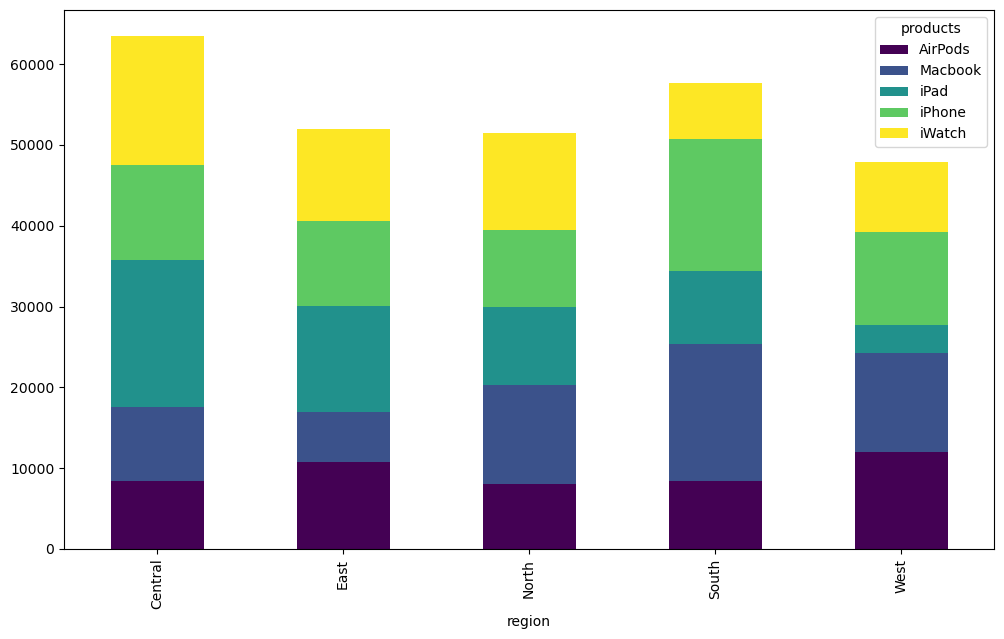

In [64]:
pivot_df.plot(
    kind='bar',
    stacked="True",
    figsize=(12,7),
    colormap='viridis'
)

Q3 

    a. Create a 3D NumPy array of shape (4, 5, 6) with random values between 100 and  200. 
    b. Compute the mean value along axis 2 and store it in a new 2D array. ]
    c. Transpose the new array and then flatten it into a 1D array. 
    d. Plot a scatter plot using the indices as x-values and the flattened values as y-values.

In [27]:
threeD_array = np.random.randint(100,201,(4,5,6))
print(threeD_array)

[[[142 158 190 135 100 154]
  [168 169 191 180 199 146]
  [154 192 152 131 198 104]
  [176 165 151 192 114 122]
  [125 141 188 110 109 185]]

 [[136 189 169 175 169 113]
  [152 198 151 131 126 176]
  [140 179 171 122 195 133]
  [197 146 109 166 178 106]
  [183 197 159 168 120 136]]

 [[141 167 180 164 174 107]
  [180 147 137 143 154 166]
  [159 106 199 104 132 130]
  [124 172 171 174 148 143]
  [159 152 181 130 127 193]]

 [[116 120 156 150 144 127]
  [178 142 185 113 179 186]
  [132 112 102 156 182 166]
  [193 139 153 117 155 125]
  [194 192 177 143 190 154]]]


In [30]:
twoD_array = threeD_array.mean(axis=2)
twoD_array

array([[146.5       , 175.5       , 155.16666667, 153.33333333,
        143.        ],
       [158.5       , 155.66666667, 156.66666667, 150.33333333,
        160.5       ],
       [155.5       , 154.5       , 138.33333333, 155.33333333,
        157.        ],
       [135.5       , 163.83333333, 141.66666667, 147.        ,
        175.        ]])

In [31]:
twoDTranspose = np.transpose(twoD_array)
twoDTranspose

array([[146.5       , 158.5       , 155.5       , 135.5       ],
       [175.5       , 155.66666667, 154.5       , 163.83333333],
       [155.16666667, 156.66666667, 138.33333333, 141.66666667],
       [153.33333333, 150.33333333, 155.33333333, 147.        ],
       [143.        , 160.5       , 157.        , 175.        ]])

In [34]:
flattend_array = twoDTranspose.flatten()
print(twoDTranspose.flatten())

[146.5        158.5        155.5        135.5        175.5
 155.66666667 154.5        163.83333333 155.16666667 156.66666667
 138.33333333 141.66666667 153.33333333 150.33333333 155.33333333
 147.         143.         160.5        157.         175.        ]


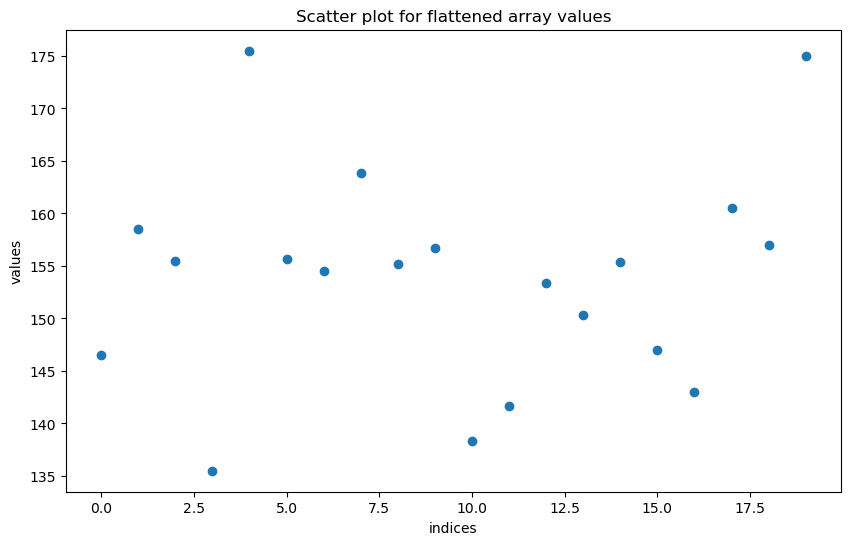

In [41]:
import matplotlib.pyplot as plt

indices = np.arange(len(flattend_array))
plt.figure(figsize=(10,6))
plt.title("Scatter plot for flattened array values")
plt.xlabel("indices")
plt.ylabel("values")
plt.scatter(indices,flattend_array)
plt.show()
